In [1]:
from score_based import *
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras.layers as layers
import keras
from math import pi

In [2]:
def generate_dataset(N, complexity = 3, d = 0.05):
    angle = tf.random.uniform((N, ), 0, complexity)
    r = angle/complexity
    return tf.stack((r*tf.cos(angle*2*pi ), r*tf.sin(angle*2*pi )), -1) + tf.random.uniform((N, 2))*d

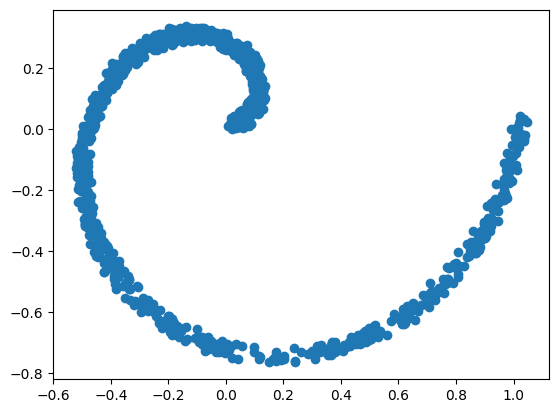

In [3]:
d = generate_dataset(1000, 1)
plt.scatter(d[:, 0], d[:, 1])
plt.show()

In [4]:
fp = VP_SDE()

In [20]:
t = tf.constant([0.3])
x0 = tf.constant([[1.0]])
index = tf.squeeze(tf.cast(tf.math.floor(t * (fp.num_steps - 1)), tf.int32))
noised, score = fp.forward(t, x0)
print("x0:", x0.numpy(), "x_t:", noised.numpy(), "score:", score.numpy())

x0: [[1.]] x_t: [[1.5144324]] score: [[-5.2991157]]


In [21]:
-(noised - tf.sqrt(fp.alphas_bar[index])*x0) / (1-fp.alphas_bar[index])

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[-5.2991166]], dtype=float32)>

In [5]:
def get_model():
    x = keras.Input(shape=(3,))
    y = layers.Dense(16, activation='relu')(x)
    y = layers.Dense(16, activation='relu')(y)
    y = layers.Dense(16, activation='relu')(y)
    y = layers.Dense(16, activation='relu')(y)
    y = layers.Dense(16, activation='relu')(y)
    y = layers.Dense(2, activation='linear')(y)
    model = keras.Model(inputs=x, outputs=y)
    return model

mse = keras.losses.MeanSquaredError()
model = get_model()
model.build(3)
model.compile(loss = mse)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,186 (4.63 KB)

 Trainable params: 1,186 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
data = tf.data.Dataset.from_tensor_slices(d)

def prep(q, y, w):
    t, x = q
    t = tf.reshape(t, (1, ))
    x = tf.concat((x, t), -1)
    return x, y, w

data = data.map(fp.map_function).map(prep)
data = data.batch(32)

In [9]:
for batch in data.take(1):
    x, y, w = batch
    print("inputs:", [xi.shape for xi in (x if isinstance(x, (tuple,list)) else [x])])
    print("targets:", y.shape)
    print("weights:", w.shape)

inputs: [TensorShape([32, 3])]
targets: (32, 2)
weights: (32,)


In [34]:
model.fit(data, epochs = 100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3432
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4263
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3972
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3619
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3785
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3658
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3851
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4022 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3953
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4306
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3914
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4061
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3934 
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4083
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3967
Ep

In [28]:
def prep_input(x, t):
    batch_size = tf.shape(x)[0]
    x = tf.cast(x, tf.float32)
    t = tf.cast(t, tf.float32)
    t = tf.fill((batch_size, 1), t)
    #t = tf.reshape(t, (batch_size, 1))
    x = tf.concat((x, t), -1)
    return tf.reshape(x, (batch_size, 3))

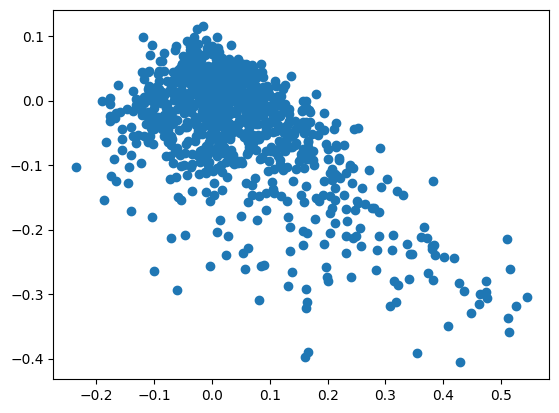

In [35]:

generated = langevin_sampling((1000, 2), lambda x, t: model(prep_input(x, t)), steps = 100, noise_scale=0.1).numpy()
plt.scatter(generated[:, 0], generated[:, 1])
plt.show()

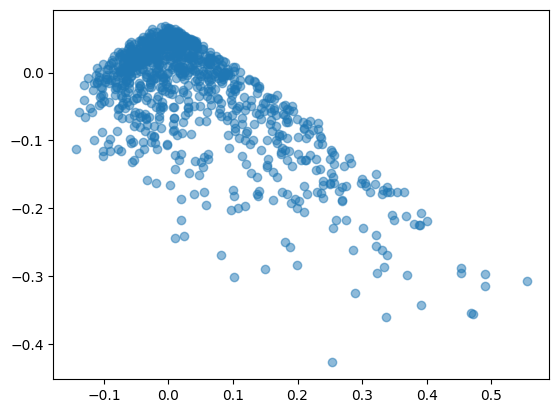

In [36]:
def generate_new_data(model, num_samples=1000, steps=100):
    dt = 1 / steps
    # Generate random input data
    state = tf.random.normal((num_samples, 2))
    # adding time dimension
    # Get the model's predictions
    for step in range(steps):
        t = step * dt
        t = 1 - t
        model_input = tf.concat([state, tf.fill((num_samples, 1), t)], axis=-1)

        state = state + model(model_input)*dt + tf.random.normal(tf.shape(state))*0.01*dt
    return state

generated_data = generate_new_data(model, num_samples=1000, steps = 100)
plt.scatter(generated_data[:, 0], generated_data[:, 1], alpha=0.5)
plt.show()

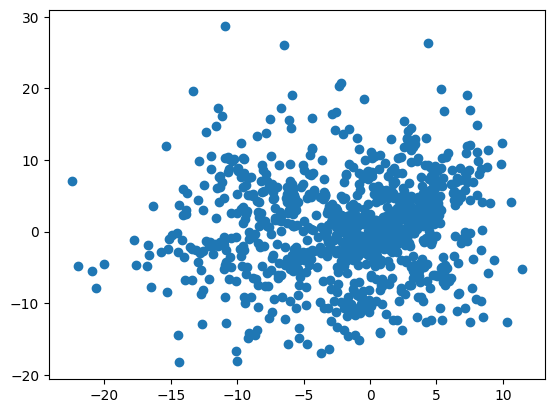

In [37]:
x = tf.random.normal((1000, 2))
t = 0.3
y = (x - model(prep_input(x, t))).numpy()
plt.scatter(y[:, 0], y[:, 1])
plt.show()

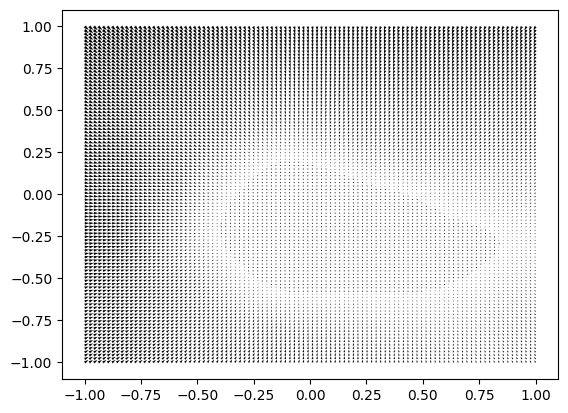

In [38]:
x, y = tf.meshgrid(tf.linspace(-1, 1, 100), tf.linspace(-1, 1, 100))
#tf.concat()
h = tf.reshape(tf.stack((x, y), -1), (100*100, 2))
v = model(prep_input(h, 0.0)).numpy().reshape((100, 100, 2))

plt.quiver(x, y, v[:, :, 0], v[:, :, 1])
plt.show()